In [60]:
import pandas as pd

In [61]:
df_job = {
    'job_id':[1,2,3,4,5],
    'job_title': ['Data Scientist','Software Engineer','Product Manager','Marketing Director','HR Manager'],
    'company_name': ['Google','Microsoft','Apple','Nike','Starbucks'],
    'job_location': ['Mountain View, CA','Redmond, WA','Cupertino, CA','Beaverton, OR','Seattle, WA']
}

df_jobs = pd.DataFrame(df_job)
df_jobs

,job_id,job_title,company_name,job_location
0,1,Data Scientist,Google,"Mountain View, CA"
1,2,Software Engineer,Microsoft,"Redmond, WA"
2,3,Product Manager,Apple,"Cupertino, CA"
3,4,Marketing Director,Nike,"Beaverton, OR"
4,5,HR Manager,Starbucks,"Seattle, WA"


In [62]:
df_company = {
    'company_name': ['Google','Microsoft','Apple','Nike','Starbucks'],
    'industry': ['Technology','Technology','Technology','Approval','Food & Beverage'],
    'company_size': ['100,000+','100,000+','100,000+','75,000+','346,000+']
}
df_companies = pd.DataFrame(df_company)
df_companies

,company_name,industry,company_size
0,Google,Technology,"100,000+"
1,Microsoft,Technology,"100,000+"
2,Apple,Technology,"100,000+"
3,Nike,Approval,"75,000+"
4,Starbucks,Food & Beverage,"346,000+"


In [63]:
df_jobs.merge(df_companies, on='company_name')

,job_id,job_title,company_name,job_location,industry,company_size
0,1,Data Scientist,Google,"Mountain View, CA",Technology,"100,000+"
1,2,Software Engineer,Microsoft,"Redmond, WA",Technology,"100,000+"
2,3,Product Manager,Apple,"Cupertino, CA",Technology,"100,000+"
3,4,Marketing Director,Nike,"Beaverton, OR",Approval,"75,000+"
4,5,HR Manager,Starbucks,"Seattle, WA",Food & Beverage,"346,000+"


In [64]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Datacleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [65]:
df_ind = df[df['job_country'] == 'India'].copy()
df_ind.loc[:,'job_posted_month'] = df_ind['job_posted_date'].dt.month_name()
df_ind_pivot = df_ind.pivot_table(index='job_posted_month',columns='job_title_short',aggfunc='size')
df_ind_pivot['Month_no'] = pd.to_datetime(df_ind_pivot.index ,format='%B').month



In [66]:
df_ind_pivot.reset_index(inplace=True)

In [71]:
df_ind_pivot.set_index('Month_no',inplace=True)

In [72]:
df_ind_pivot = df_ind_pivot.sort_index()

In [74]:
df_ind_pivot.set_index('job_posted_month',inplace=True)

In [75]:
df_ind_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,175,31,628,2132,1444,70,127,448,269,192
February,143,35,433,1631,932,42,94,313,165,157
March,116,37,422,1591,1005,34,96,351,194,180
April,170,32,418,1566,946,54,86,375,194,169
May,103,14,278,1384,837,31,59,329,134,98
June,146,26,367,1632,1129,41,66,427,238,125
July,142,25,457,1528,1123,54,75,359,204,155
August,189,25,618,1407,1157,47,126,343,235,148
September,155,34,630,1508,984,67,85,324,195,132


In [78]:
df_ind_software_pivot = pd.read_csv("https://lukeb.co/software_csv", index_col='job_posted_month')
df_ind_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [80]:
df_ind_merged = df_ind_pivot.merge(df_ind_software_pivot, on='job_posted_month')

In [ ]:
top_5 = (df_ind_merged
         .sum()
         .sort_values(ascending=False)
         .head()
         .index
         .to_list()
         )

top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'UI/UX Designer',
 'Data Engineer']

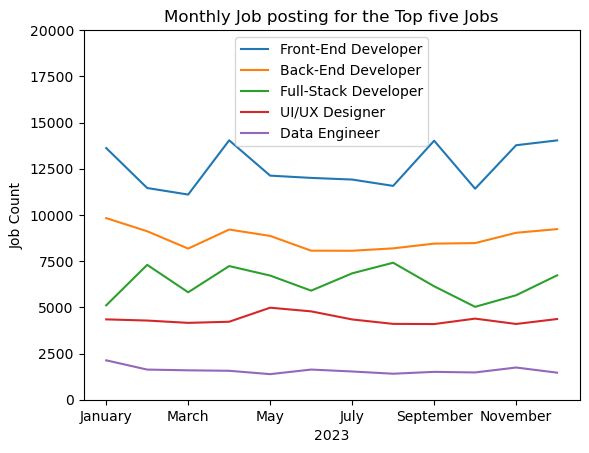

In [88]:
df_ind_merged[top_5].plot(kind='line')
plt.title('Monthly Job posting for the Top five Jobs')
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.legend()
plt.ylim(0,20000)
plt.show()